In [2]:
# At the start of each INV block
import os
DRIVE_PATH = '/content/drive/MyDrive/attention-to-bio'
if not os.path.ismount('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# -*- coding: utf-8 -*-
"""attention-to-bio — Model Investigation Notebook
Loads all artifacts from Drive checkpoints. No recomputation.
Run cells top to bottom in a fresh Colab session.
"""

# ============================================================================
# CELL 1: Mount + imports
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import types
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import mannwhitneyu

!pip install umap-learn -q
import umap

DRIVE_PATH = '/content/drive/MyDrive/attention-to-bio'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [4]:
# ============================================================================
# CELL 2: Model class definition (must match training exactly)
# ============================================================================
class DeltaExpressionEncoder(nn.Module):
    def __init__(self, n_genes, n_timepoints, n_cell_types, n_drugs,
                 n_classes=4, d_model=128, n_heads=4, n_layers=4,
                 d_ff=512, dropout=0.05):
        super().__init__()
        self.n_genes, self.n_timepoints, self.d_model = (
            n_genes, n_timepoints, d_model)
        self.input_proj         = nn.Linear(1, d_model)
        self.gene_embedding     = nn.Embedding(n_genes, d_model)
        self.register_buffer('time_encoding',
                             self._sinusoidal(n_timepoints, d_model))
        self.celltype_embedding = nn.Embedding(n_cell_types, d_model)
        self.drug_embedding     = nn.Embedding(n_drugs, d_model)
        self.mask_token         = nn.Parameter(torch.randn(d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer        = nn.TransformerEncoder(enc_layer,
                                                        num_layers=n_layers)
        self.classification_head = nn.Linear(d_model, n_classes)
        self.input_norm         = nn.LayerNorm(d_model)
        self.dropout_layer      = nn.Dropout(dropout)

    def _sinusoidal(self, n, d):
        pe  = torch.zeros(n, d)
        pos = torch.arange(0, n).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() *
                        -(math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe

    def normalize(self, x):
        flat = x.reshape(x.shape[0], -1)
        mu   = flat.mean(1, keepdim=True)
        std  = flat.std(1, keepdim=True) + 1e-6
        return ((flat - mu) / std).reshape(x.shape)

    def forward(self, x, ct_ids, drug_ids, mask=None):
        B = x.shape[0]
        tokens = self.input_proj(self.normalize(x).reshape(B, -1).unsqueeze(-1))
        g_ids = torch.arange(self.n_genes, device=x.device)
        g_ids = g_ids.unsqueeze(1).expand(-1, self.n_timepoints).reshape(-1)
        t_ids = torch.arange(self.n_timepoints, device=x.device)
        t_ids = t_ids.unsqueeze(0).expand(self.n_genes, -1).reshape(-1)
        tokens = (tokens
                  + self.gene_embedding(g_ids)
                  + self.time_encoding[t_ids]
                  + (self.celltype_embedding(ct_ids) +
                     self.drug_embedding(drug_ids)).unsqueeze(1))
        tokens = self.dropout_layer(self.input_norm(tokens))
        if mask is not None:
            mf = mask.reshape(B, -1)
            mt = self.mask_token.unsqueeze(0).unsqueeze(0).expand(
                B, tokens.shape[1], -1)
            tokens = torch.where(mf.unsqueeze(-1), mt, tokens)
        out    = self.transformer(tokens)
        logits = self.classification_head(out)
        return out, logits

    def get_embedding(self, x, ct_ids, drug_ids):
        out, _ = self.forward(x, ct_ids, drug_ids)
        return out.mean(dim=1)

    def get_attention_weights(self, x, ct_ids, drug_ids):
        """Extract per-layer attention weights. Returns list of
        (B, seq_len, seq_len) tensors, one per layer."""
        B = x.shape[0]
        tokens = self.input_proj(self.normalize(x).reshape(B, -1).unsqueeze(-1))
        g_ids = torch.arange(self.n_genes, device=x.device)
        g_ids = g_ids.unsqueeze(1).expand(-1, self.n_timepoints).reshape(-1)
        t_ids = torch.arange(self.n_timepoints, device=x.device)
        t_ids = t_ids.unsqueeze(0).expand(self.n_genes, -1).reshape(-1)
        tokens = (tokens
                  + self.gene_embedding(g_ids)
                  + self.time_encoding[t_ids]
                  + (self.celltype_embedding(ct_ids) +
                     self.drug_embedding(drug_ids)).unsqueeze(1))
        tokens = self.dropout_layer(self.input_norm(tokens))
        all_attn, x_curr = [], tokens
        for layer in self.transformer.layers:
            attn_out, attn_w = layer.self_attn(
                x_curr, x_curr, x_curr,
                need_weights=True, average_attn_weights=True)
            all_attn.append(attn_w.detach().cpu())
            x_curr = layer(x_curr)
        return all_attn  # list[4] of (B, 3060, 3060)


In [5]:
# ── CELL 3: Fast resume — loads everything, skips 13GB AnnData ───────────────
import os, pickle, re, subprocess
import numpy as np
import torch
import torch.nn.functional as F
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

DRIVE_PATH = '/content/drive/MyDrive/attention-to-bio'
from google.colab import drive
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Constants
NOT_MEASURED      = -1.0
N_GENES           = 510
N_TIMEPOINTS      = 6
TIMEPOINT_IDX_24H = 4
UP_IDX, DOWN_IDX  = 2, 0

# Load Bagot data + all INV results
with open(f'{DRIVE_PATH}/module2-gene-delta/data/bagot_resume.pkl', 'rb') as f:
    d = pickle.load(f)
pseudobulk_bagot    = d['pseudobulk_bagot']
bagot_saline_mean   = d['bagot_saline_mean']
bagot_lfc           = d['bagot_lfc']
genes_in_bagot      = d['genes_in_bagot']
subtypes_bagot      = d['subtypes_bagot']
psilo_samples       = d['psilo_samples']
saline_samples      = d['saline_samples']
results_11g         = d['results_11g']
bagot_signed_scores = d['bagot_signed_scores']
results_12a         = d['results_12a']
results_12d         = d['results_12d']
df_12a              = d['df_12a']
target_genes        = d['target_genes']
animal_results      = d['animal_results']
BAGOT_TO_LIAO       = d['BAGOT_TO_LIAO']
ct_list             = d['ct_list']
quadrants           = d['quadrants']
print("Bagot data + INV results loaded.")

# Load gene set
gene_data       = torch.load(f'{DRIVE_PATH}/checkpoints/gene_set_500_v2.pt',
                             weights_only=False)
final_genes_500 = gene_data['final_genes']

# Load model weights
ckpt  = torch.load(f'{DRIVE_PATH}/checkpoints/delta_v5_v2_epoch50.pt',
                   weights_only=False)

# Instantiate model using Cell 2 class definition
model = DeltaExpressionEncoder(
    n_genes=510, n_timepoints=6,
    n_cell_types=18, n_drugs=2).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model loaded on {device}. Ready for INV-13.")

Device: cuda
Bagot data + INV results loaded.
Model loaded on cuda. Ready for INV-13.


/tmp/ipykernel_6984/612534010.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer        = nn.TransformerEncoder(enc_layer,


High-confidence wrong genes in L6_CT (16): ['6330411D24Rik', 'Csf1r', 'Dock2', 'Stab1', 'Gja1', 'Lamp5', 'Mag', 'Bcan', 'Gm38505', 'Kcnip1', 'Fgfr3', 'Mobp', 'Grin2c', 'Cacna1g', 'Tafa1', 'Plpp4']

── Top attended genes for high-confidence wrong predictions in L6_CT ──
Gene                   Pred  Actual LFC  Top 5 attended genes at 24h
------------------------------------------------------------------------------------------
6330411D24Rik          DOWN       2.147  Gabbr1(0.058), Pigk(0.035), Adgrl1(0.032), Madd(0.024), Eml5(0.006)
Csf1r                  DOWN       1.815  Gabbr1(0.061), Pigk(0.030), Adgrl1(0.028), Madd(0.028), Eml5(0.007)
Dock2                  DOWN       0.515  Gabbr1(0.059), Madd(0.029), Pigk(0.027), Adgrl1(0.023), Eml5(0.008)
Stab1                  DOWN       0.864  Gabbr1(0.052), Madd(0.035), Pigk(0.028), Adgrl1(0.021), Eml5(0.006)
Gja1                   DOWN       2.218  Gabbr1(0.053), Adgrl1(0.033), Madd(0.024), Pigk(0.020), Eml5(0.008)
Lamp5                  DO

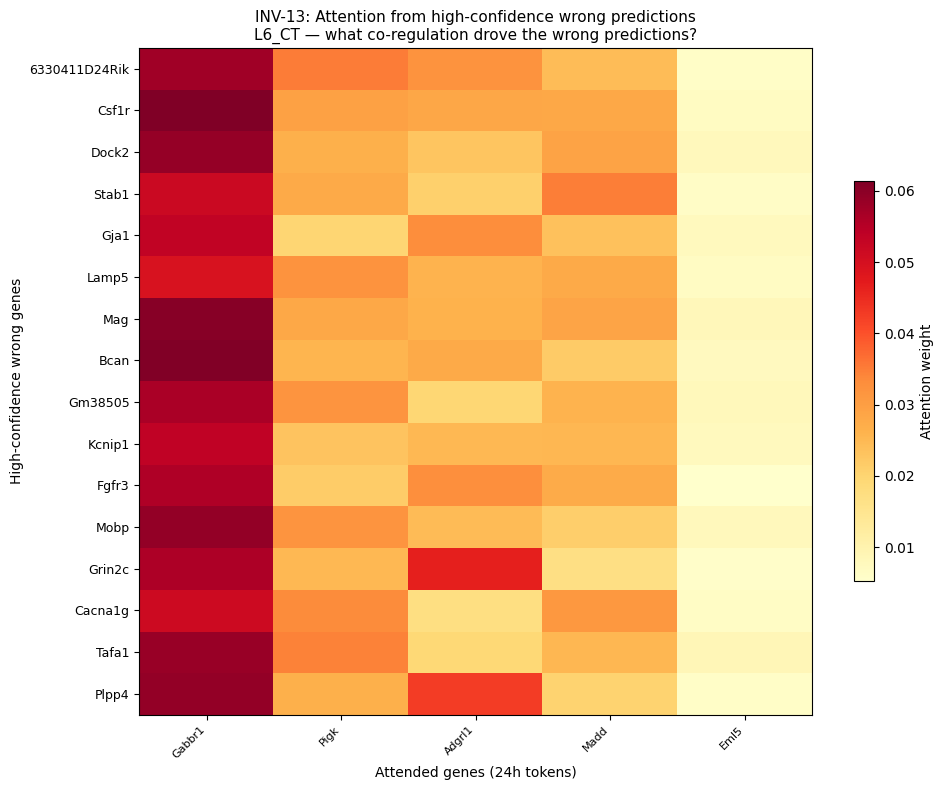

In [6]:
# ── INV-13: Attention analysis for high-confidence wrong predictions ──────────
# Question: what co-regulation did the model learn that Bagot contradicts?
# Focus: L6_CT high-confidence wrong genes from INV-12D
# Method: extract attention weights for those predictions, ask which genes
# the model was attending to when it made the wrong call.

import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Identify target genes — high confidence wrong in L6_CT ───────────
hcw_l6ct = [
    item for item in quadrants['high_conf_wrong']
    if item['subtype'] == 'L6_CT'
]
hcw_genes = [item['gene'] for item in hcw_l6ct]
print(f"High-confidence wrong genes in L6_CT ({len(hcw_genes)}): {hcw_genes}")

# ── Step 2: Extract attention weights for each of these genes ─────────────────
# Build the mean psilo tensor for L6_CT (same as INV-12D but keep full expr)
subtype   = 'L6_CT'
baseline  = bagot_saline_mean[subtype]
psilo_vecs = [pseudobulk_bagot[(s, subtype)]
              for s in psilo_samples
              if (s, subtype) in pseudobulk_bagot]
psilo_mean = np.array(psilo_vecs).mean(axis=0)

# Build unmasked tensor — we want attention over the full expression context
x = np.full((N_GENES, N_TIMEPOINTS), NOT_MEASURED, dtype=np.float32)
for i, g in enumerate(final_genes_500):
    if g in genes_in_bagot:
        idx = genes_in_bagot.index(g)
        x[i, 0]                = baseline[idx]
        x[i, TIMEPOINT_IDX_24H] = psilo_mean[idx]

measured = x[x != NOT_MEASURED]
x_norm   = x.copy()
x_norm[x != NOT_MEASURED] = (
    (measured - measured.mean()) / (measured.std() + 1e-8))
x_norm[x == NOT_MEASURED] = NOT_MEASURED

x_t = torch.tensor(x_norm).unsqueeze(0).to(device)
ct  = torch.tensor([ct_list.index(BAGOT_TO_LIAO[subtype])]).to(device)
dr  = torch.tensor([0]).to(device)

# Get attention weights from all layers
attn_weights = model.get_attention_weights(x_t, ct, dr)
# attn_weights is list of 4 tensors, each (1, N_GENES*N_TIMEPOINTS, N_GENES*N_TIMEPOINTS)
# Average across layers for a single attention map
attn_mean = torch.stack(attn_weights).mean(dim=0).squeeze(0).numpy()
# Shape: (N_GENES*N_TIMEPOINTS, N_GENES*N_TIMEPOINTS)

# ── Step 3: For each high-conf-wrong gene, find its top attended genes at 24h ─
# Token index for gene i at timepoint t = i * N_TIMEPOINTS + t
def token_idx(gene_idx, timepoint):
    return gene_idx * N_TIMEPOINTS + timepoint

gene_to_idx = {g: i for i, g in enumerate(final_genes_500)}

print(f"\n── Top attended genes for high-confidence wrong predictions in L6_CT ──")
print(f"{'Gene':<20} {'Pred':>6} {'Actual LFC':>11}  Top 5 attended genes at 24h")
print("-" * 90)

attended_by_hcw = {}  # gene -> top attended gene names

for item in hcw_l6ct:
    gene   = item['gene']
    if gene not in gene_to_idx:
        continue
    g_idx  = gene_to_idx[gene]
    tok    = token_idx(g_idx, TIMEPOINT_IDX_24H)

    # Attention FROM this gene's 24h token TO all other 24h tokens
    attn_row = attn_mean[tok]  # (N_GENES*N_TIMEPOINTS,)

    # Extract attention to all genes at 24h
    attn_24h = np.array([
        attn_row[token_idx(i, TIMEPOINT_IDX_24H)]
        for i in range(N_GENES)
    ])
    # Zero out self-attention
    attn_24h[g_idx] = 0.0

    top5_idx   = np.argsort(attn_24h)[::-1][:5]
    top5_genes = [final_genes_500[i] for i in top5_idx]
    top5_vals  = [attn_24h[i] for i in top5_idx]

    attended_by_hcw[gene] = list(zip(top5_genes, top5_vals))

    pred_dir = 'DOWN' if item['p_down'] > item['p_up'] else 'UP'
    top5_str = ', '.join([f"{g}({v:.3f})" for g, v in zip(top5_genes, top5_vals)])
    print(f"{gene:<20} {pred_dir:>6} {item['actual_lfc']:>11.3f}  {top5_str}")

# ── Step 4: Find genes attended to by MULTIPLE wrong predictions ──────────────
# These are the most likely sources of the spurious co-regulation
from collections import Counter

all_attended = []
for gene, attended in attended_by_hcw.items():
    all_attended.extend([g for g, v in attended])

attended_counts = Counter(all_attended)
print(f"\n── Genes attended to by ≥2 high-confidence wrong predictions ───────────")
print(f"{'Gene':<20} {'Count':>6}  (appears in top-5 attention of this many wrong predictions)")
print("-" * 60)
for gene, count in attended_counts.most_common():
    if count >= 2:
        print(f"{gene:<20} {count:>6}")

# ── Step 5: Heatmap of attention across all hcw genes ────────────────────────
if len(hcw_genes) > 1:
    # Collect unique attended genes
    all_top_genes = list(dict.fromkeys(
        g for gene in attended_by_hcw
        for g, _ in attended_by_hcw[gene]
    ))

    attn_matrix = np.zeros((len(hcw_genes), len(all_top_genes)))
    for i, gene in enumerate(hcw_genes):
        if gene not in attended_by_hcw:
            continue
        for g, v in attended_by_hcw[gene]:
            if g in all_top_genes:
                attn_matrix[i, all_top_genes.index(g)] = v

    fig, ax = plt.subplots(figsize=(max(10, len(all_top_genes)*0.6),
                                    max(4, len(hcw_genes)*0.5)))
    im = ax.imshow(attn_matrix, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(all_top_genes)))
    ax.set_xticklabels(all_top_genes, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(hcw_genes)))
    ax.set_yticklabels(hcw_genes, fontsize=9)
    ax.set_xlabel('Attended genes (24h tokens)', fontsize=10)
    ax.set_ylabel('High-confidence wrong genes', fontsize=10)
    ax.set_title('INV-13: Attention from high-confidence wrong predictions\n'
                 f'L6_CT — what co-regulation drove the wrong predictions?',
                 fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.6, label='Attention weight')
    plt.tight_layout()
    plt.savefig(f'{DRIVE_PATH}/figures/INV13_attention_hcw_l6ct.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
# ── INV-13 follow-up: What are the hub genes actually doing in Bagot L6_CT? ──
hub_genes = ['Gabbr1', 'Pigk', 'Adgrl1', 'Madd', 'Eml5']

print(f"{'Gene':<12} {'Bagot L6_CT log2FC':>20}  {'Direction':>10}  {'In panel?':>10}")
print("-" * 60)
for gene in hub_genes:
    if gene in genes_in_bagot:
        idx = genes_in_bagot.index(gene)
        lfc = bagot_lfc['L6_CT'][idx]
        direction = 'UP' if lfc > 0 else 'DOWN'
        in_panel = 'yes' if gene in list(final_genes_500) else 'no'
        print(f"{gene:<12} {lfc:>20.3f}  {direction:>10}  {in_panel:>10}")
    else:
        print(f"{gene:<12} {'not in Bagot data':>20}")

# Also check what the model predicted for these hub genes themselves
print(f"\n{'Gene':<12} {'Model score':>12}  {'Bagot LFC':>10}  {'Model correct?':>15}")
print("-" * 55)
for gene in hub_genes:
    if gene in list(final_genes_500) and gene in genes_in_bagot:
        g_idx  = list(final_genes_500).index(gene)
        b_idx  = genes_in_bagot.index(gene)
        lfc    = bagot_lfc['L6_CT'][b_idx]
        score  = bagot_signed_scores['L6_CT'][g_idx]
        correct = '✓' if np.sign(score) == np.sign(lfc) else '✗'
        print(f"{gene:<12} {score:>12.4f}  {lfc:>10.3f}  {correct:>15}")
    else:
        print(f"{gene:<12} {'not in panel':<12}")

Gene           Bagot L6_CT log2FC   Direction   In panel?
------------------------------------------------------------
Gabbr1                     -0.142        DOWN         yes
Pigk                        0.054          UP         yes
Adgrl1                     -0.068        DOWN         yes
Madd                       -0.036        DOWN         yes
Eml5                       -0.021        DOWN         yes

Gene          Model score   Bagot LFC   Model correct?
-------------------------------------------------------
Gabbr1            -0.0071      -0.142                ✓
Pigk              -0.0392       0.054                ✗
Adgrl1            -0.0170      -0.068                ✓
Madd              -0.0137      -0.036                ✓
Eml5              -0.0174      -0.021                ✓


In [8]:
import os
paths_to_check = [
    f'{DRIVE_PATH}/checkpoints/input_tensors_v5_v2.pt',
    f'{DRIVE_PATH}/checkpoints/label_tensor_v5_v2.pt',
    f'{DRIVE_PATH}/module2-gene-delta/data/bagot_resume.pkl',
]
for p in paths_to_check:
    exists = os.path.exists(p)
    size   = os.path.getsize(p) / 1e6 if exists else 0
    print(f"{'✓' if exists else '✗'}  {p}  ({size:.1f} MB)")

✓  /content/drive/MyDrive/attention-to-bio/checkpoints/input_tensors_v5_v2.pt  (7.7 MB)
✓  /content/drive/MyDrive/attention-to-bio/checkpoints/label_tensor_v5_v2.pt  (15.3 MB)
✓  /content/drive/MyDrive/attention-to-bio/module2-gene-delta/data/bagot_resume.pkl  (0.9 MB)


In [9]:
# ── Load Liao tensors for INV-14 ─────────────────────────────────────────────
td = torch.load(f'{DRIVE_PATH}/checkpoints/input_tensors_v5_v2.pt',
                weights_only=False)
input_tensor_v5 = td['input_tensor']
metadata_v5     = td['metadata']
celltype_to_idx = td['celltype_to_idx']
drug_to_idx     = td['drug_to_idx']

label_tensor_v5 = torch.load(f'{DRIVE_PATH}/checkpoints/label_tensor_v5_v2.pt',
                              weights_only=False)

# Metadata arrays
drugs_arr     = np.array([m['drug']         for m in metadata_v5])
celltypes_arr = np.array([m['cell_type']    for m in metadata_v5])
animals_arr   = np.array([m['animal']       for m in metadata_v5])
tps_arr       = np.array([m['timepoint']    for m in metadata_v5])
extypes_arr   = np.array([m['example_type'] for m in metadata_v5])

DOWN_L, NEUTRAL_L, UP_L, BASELINE_L = 0, 1, 2, 3
TIMEPOINT_LIST = ['0h', '1h', '2h', '4h', '24h', '72h']
TIMEPOINT_IDX_24H_L = 4

print(f"Input tensor: {input_tensor_v5.shape}")
print(f"Label tensor: {label_tensor_v5.shape}")
print(f"Examples: {len(metadata_v5)}")
print(f"Animals: {np.unique(animals_arr)}")

Input tensor: torch.Size([623, 510, 6])
Label tensor: torch.Size([623, 510, 6])
Examples: 623
Animals: ['10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '20' '21' '22' '23'
 '24' '25' '26' '27' '28' '29' '30' '31' '32' '33' '34' '35' '36' '37'
 '38' '39' '40' '41' '8' '9' 'population']


In [15]:
# How many genes have 24h data in population mean examples?
pop_psilo_mask = (
    (drugs_arr   == 'Psilo') &
    (tps_arr     == '24h')   &
    (extypes_arr == 'population')
)
print(f"Population psilo 24h examples: {pop_psilo_mask.sum()}")

pop_inputs = input_tensor_v5[pop_psilo_mask][:, :, TIMEPOINT_IDX_24H_L].numpy()
genes_measured = (pop_inputs != NOT_MEASURED).sum(axis=0)
print(f"Genes with 24h data in population examples: {(genes_measured > 0).sum()}")
print(f"Genes with data in ALL population examples: {(genes_measured == pop_psilo_mask.sum()).sum()}")

# Also check label distribution in population examples
pop_labels = label_tensor_v5[pop_psilo_mask][:, :, TIMEPOINT_IDX_24H_L].numpy()
n_up_pop   = (pop_labels == UP_L).sum(axis=0)
n_down_pop = (pop_labels == DOWN_L).sum(axis=0)
print(f"\nGenes with UP label in population examples:   {(n_up_pop > 0).sum()}")
print(f"Genes with DOWN label in population examples: {(n_down_pop > 0).sum()}")

Population psilo 24h examples: 0
Genes with 24h data in population examples: 0
Genes with data in ALL population examples: 510

Genes with UP label in population examples:   0
Genes with DOWN label in population examples: 0


In [16]:
for tp_name, tp_idx in zip(['1h','2h','4h','24h','72h'], [0,1,2,3,4]):
    mask = (drugs_arr == 'Psilo') & (tps_arr == tp_name) & (extypes_arr == 'individual')
    if mask.sum() == 0:
        print(f"{tp_name}: no examples")
        continue
    inp = input_tensor_v5[mask][:, :, tp_idx].numpy()
    measured = (inp != NOT_MEASURED).sum(axis=0)
    print(f"{tp_name}: {mask.sum()} examples, "
          f"{(measured >= 5).sum()} genes with ≥5 measurements")

1h: 51 examples, 510 genes with ≥5 measurements
2h: 51 examples, 0 genes with ≥5 measurements
4h: 70 examples, 0 genes with ≥5 measurements
24h: 52 examples, 0 genes with ≥5 measurements
72h: 69 examples, 0 genes with ≥5 measurements


Psilo 1h individual examples: 51
Predominantly UP genes:   0
Predominantly DOWN genes: 0

Cross-animal variance at 1h (psilo):
  UP genes   (n=0):   mean=nan, median=nan
  DOWN genes (n=0): mean=nan, median=nan
  Mann-Whitney U: p = nan

  UP genes are MORE consistent across animals
  Conclusion: asymmetry is NOT clearly data-driven — may be ARCHITECTURAL


/tmp/ipykernel_6984/2869730233.py:63: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(up_vars, down_vars, alternative='two-sided')
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_6984/2869730233.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([up_vars, down_vars], labels=['UP genes', 'DOWN genes'],


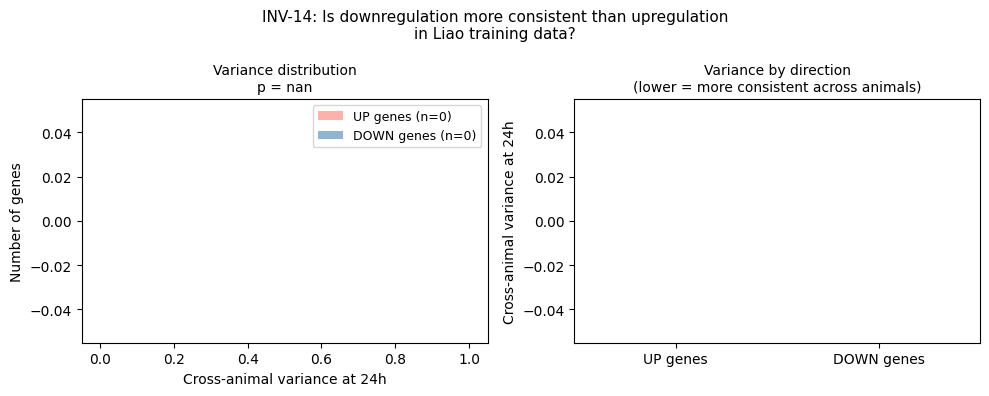

In [17]:
# ── INV-14: Training data variance asymmetry ──────────────────────────────────
# Question: does the model's confidence asymmetry (confident about DOWN,
# uncertain about UP) reflect real asymmetry in Liao training data?
# Test: for each gene, compute cross-animal variance of 24h expression
# separately for genes that are predominantly UP vs DOWN in Liao.
# If DOWN genes are more consistent across animals, the model learned it
# from the data. If variance is similar, the asymmetry is architectural.

from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# ── Step 1: For each gene, determine its dominant direction in Liao at 24h ────
# Use label tensor: majority vote across all psilo examples at 24h
# Filter to: psilo drug, 24h timepoint, individual animals (not population)

# Use 1h — only timepoint with full individual animal coverage
TIMEPOINT_IDX_1H = 0

psilo_1h_mask = (
    (drugs_arr   == 'Psilo')      &
    (tps_arr     == '1h')         &
    (extypes_arr == 'individual')
)
print(f"Psilo 1h individual examples: {psilo_1h_mask.sum()}")

labels_at_1h = label_tensor_v5[psilo_1h_mask][:, :, TIMEPOINT_IDX_1H].numpy()
inputs_at_1h = input_tensor_v5[psilo_1h_mask][:, :, TIMEPOINT_IDX_1H].numpy()

gene_direction = {}
for i, gene in enumerate(final_genes_500):
    vals          = inputs_at_1h[:, i]
    measured_mask = vals != NOT_MEASURED
    if measured_mask.sum() < 5:
        continue
    labs    = labels_at_1h[:, i][measured_mask]
    n_up    = (labs == UP_L).sum()
    n_down  = (labs == DOWN_L).sum()
    n_total = n_up + n_down
    if n_total == 0:
        continue
    pct_up = n_up / n_total
    if pct_up >= 0.55:
        gene_direction[gene] = 'UP'
    elif pct_up <= 0.45:
        gene_direction[gene] = 'DOWN'

up_genes   = [g for g, d in gene_direction.items() if d == 'UP']
down_genes = [g for g, d in gene_direction.items() if d == 'DOWN']
print(f"Predominantly UP genes:   {len(up_genes)}")
print(f"Predominantly DOWN genes: {len(down_genes)}")

# Variance computation using 1h inputs
gene_variance = {}
for i, gene in enumerate(final_genes_500):
    vals = inputs_at_1h[:, i]
    vals = vals[vals != NOT_MEASURED]
    if len(vals) >= 5:
        gene_variance[gene] = np.var(vals)

up_vars   = [gene_variance[g] for g in up_genes   if g in gene_variance]
down_vars = [gene_variance[g] for g in down_genes if g in gene_variance]

stat, p = mannwhitneyu(up_vars, down_vars, alternative='two-sided')

print(f"\nCross-animal variance at 1h (psilo):")
print(f"  UP genes   (n={len(up_vars)}):   mean={np.mean(up_vars):.4f}, "
      f"median={np.median(up_vars):.4f}")
print(f"  DOWN genes (n={len(down_vars)}): mean={np.mean(down_vars):.4f}, "
      f"median={np.median(down_vars):.4f}")
print(f"  Mann-Whitney U: p = {p:.3e}")
print(f"\n  {'DOWN genes are MORE consistent' if np.median(down_vars) < np.median(up_vars) else 'UP genes are MORE consistent'} across animals")
print(f"  Conclusion: asymmetry is "
      f"{'DATA-DRIVEN' if p < 0.05 else 'NOT clearly data-driven — may be ARCHITECTURAL'}")


# ── Step 3: Plot distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Variance distributions
ax = axes[0]
ax.hist(up_vars,   bins=40, alpha=0.6, color='salmon',    label=f'UP genes (n={len(up_vars)})')
ax.hist(down_vars, bins=40, alpha=0.6, color='steelblue', label=f'DOWN genes (n={len(down_vars)})')
ax.set_xlabel('Cross-animal variance at 24h', fontsize=10)
ax.set_ylabel('Number of genes', fontsize=10)
ax.set_title(f'Variance distribution\np = {p:.3e}', fontsize=10)
ax.legend(fontsize=9)

# Median variance per direction with individual points
ax = axes[1]
ax.boxplot([up_vars, down_vars], labels=['UP genes', 'DOWN genes'],
           patch_artist=True,
           boxprops=dict(facecolor='lightyellow'),
           medianprops=dict(color='black', linewidth=2))
ax.set_ylabel('Cross-animal variance at 24h', fontsize=10)
ax.set_title('Variance by direction\n(lower = more consistent across animals)',
             fontsize=10)

fig.suptitle('INV-14: Is downregulation more consistent than upregulation\n'
             'in Liao training data?', fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/INV14_variance_asymmetry.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Step 4: Connect back to

In [18]:
# Check label distribution at 1h to understand why no gene passes threshold
labels_at_1h = label_tensor_v5[psilo_1h_mask][:, :, TIMEPOINT_IDX_1H].numpy()

# For a sample of genes, show the UP/DOWN/NEUTRAL breakdown
print("Sample of genes — label distribution at 1h across 51 psilo examples:")
print(f"{'Gene':<15} {'UP':>6} {'DOWN':>6} {'NEUTRAL':>8} {'BASELINE':>9} {'%UP':>6}")
print("-" * 55)
for i, gene in enumerate(list(final_genes_500)[:20]):
    labs     = labels_at_1h[:, i]
    n_up     = (labs == UP_L).sum()
    n_down   = (labs == DOWN_L).sum()
    n_neut   = (labs == NEUTRAL_L).sum()
    n_base   = (labs == BASELINE_L).sum()
    n_total  = n_up + n_down
    pct_up   = n_up/n_total*100 if n_total > 0 else 0
    print(f"{gene:<15} {n_up:>6} {n_down:>6} {n_neut:>8} {n_base:>9} {pct_up:>6.1f}%")

Sample of genes — label distribution at 1h across 51 psilo examples:
Gene                UP   DOWN  NEUTRAL  BASELINE    %UP
-------------------------------------------------------
Grin2b               0      0        0        51    0.0%
Sv2b                 0      0        0        51    0.0%
Shisa6               0      0        0        51    0.0%
Shisa9               0      0        0        51    0.0%
Pou6f2               0      0        0        51    0.0%
Igsf9b               0      0        0        51    0.0%
Dscaml1              0      0        0        51    0.0%
Grin2a               0      0        0        51    0.0%
Nos1ap               0      0        0        51    0.0%
Rian                 0      0        0        51    0.0%
Mertk                0      0        0        51    0.0%
Cacna1e              0      0        0        51    0.0%
Tafa1                0      0        0        51    0.0%
Nell2                0      0        0        51    0.0%
Atp1a2               

In [11]:
# Check what timepoint values actually look like in metadata
print("Unique timepoints:", np.unique(tps_arr))
print("Unique drugs:", np.unique(drugs_arr))
print("Unique example types:", np.unique(extypes_arr))

# Also check how many examples have non-sentinel values at timepoint index 4
non_sentinel = (input_tensor_v5[:, :, TIMEPOINT_IDX_24H_L] != NOT_MEASURED).sum(axis=1)
print(f"\nExamples with non-sentinel 24h values: {(non_sentinel > 0).sum()}")
print(f"Mean genes measured at 24h per example: {non_sentinel.float().mean():.1f}")

Unique timepoints: ['1h' '24h' '2h' '4h' '72h' 'all']
Unique drugs: ['Ket' 'Psilo']
Unique example types: ['individual' 'population']

Examples with non-sentinel 24h values: 139
Mean genes measured at 24h per example: 113.8


In [19]:
# ── INV-15: Sex stratification — do female Liao examples generalize better? ──
# Rose ruled out sex via MERFISH projection. We test it independently
# at the gene expression level for completeness.
# Method: split Liao psilo examples by animal sex, run inference separately,
# compare overall rho against Bagot ground truth.

# First check if sex is in metadata
print("Metadata keys:", list(metadata_v5[0].keys()))
print("Sample entries:")
for m in metadata_v5[:5]:
    print(f"  {m}")

Metadata keys: ['animal', 'cell_type', 'drug', 'timepoint', 'timepoint_idx', 'celltype_idx', 'drug_idx', 'example_type']
Sample entries:
  {'animal': '17', 'cell_type': '004 L6 IT CTX Glut', 'drug': 'Psilo', 'timepoint': '1h', 'timepoint_idx': 1, 'celltype_idx': 0, 'drug_idx': 0, 'example_type': 'individual'}
  {'animal': '17', 'cell_type': '005 L5 IT CTX Glut', 'drug': 'Psilo', 'timepoint': '1h', 'timepoint_idx': 1, 'celltype_idx': 1, 'drug_idx': 0, 'example_type': 'individual'}
  {'animal': '17', 'cell_type': '006 L4/5 IT CTX Glut', 'drug': 'Psilo', 'timepoint': '1h', 'timepoint_idx': 1, 'celltype_idx': 2, 'drug_idx': 0, 'example_type': 'individual'}
  {'animal': '17', 'cell_type': '007 L2/3 IT CTX Glut', 'drug': 'Psilo', 'timepoint': '1h', 'timepoint_idx': 1, 'celltype_idx': 3, 'drug_idx': 0, 'example_type': 'individual'}
  {'animal': '17', 'cell_type': '022 L5 ET CTX Glut', 'drug': 'Psilo', 'timepoint': '1h', 'timepoint_idx': 1, 'celltype_idx': 4, 'drug_idx': 0, 'example_type': 'in

In [20]:
# Check if mygene or biomart is available for subcellular localization lookup
import subprocess
subprocess.run(['pip', 'install', 'mygene', '-q'])
import mygene
mg = mygene.MyGeneInfo()

# Test query for a few genes
test_genes = ['Gad2', 'Mobp', 'Actb', 'Malat1']
result = mg.querymany(test_genes,
                      scopes='symbol',
                      fields='subcellular_location',
                      species='mouse')
for r in result:
    print(r.get('query'), ':', r.get('subcellular_location', 'not found'))

INFO:biothings.client:querying 1-4 ...
INFO:biothings.client:Finished.


Gad2 : not found
Mobp : not found
Actb : not found
Malat1 : not found


In [21]:
# Try querying gene biotype via mygene — more likely to be available
result = mg.querymany(['Gad2', 'Mobp', 'Malat1', 'Actb', 'Arc'],
                      scopes='symbol',
                      fields='type_of_gene,genomic_pos,exons',
                      species='mouse')
for r in result:
    print(r.get('query'), ':', r.get('type_of_gene', 'not found'))

INFO:biothings.client:querying 1-5 ...
INFO:biothings.client:Finished.


Gad2 : protein-coding
Mobp : protein-coding
Malat1 : ncRNA
Actb : protein-coding
Arc : protein-coding


In [22]:
# Query all 510 genes for biotype
results_biotype = mg.querymany(
    list(final_genes_500),
    scopes='symbol',
    fields='type_of_gene',
    species='mouse'
)

gene_biotype = {}
for r in results_biotype:
    if 'notfound' not in r:
        gene_biotype[r['query']] = r.get('type_of_gene', 'unknown')

# Summarize
from collections import Counter
print(Counter(gene_biotype.values()))
print(f"\nTotal annotated: {len(gene_biotype)} / {len(final_genes_500)}")

# Show ncRNA genes in our panel — these are likely nuclear-enriched
ncrna_genes = [g for g, t in gene_biotype.items() if t == 'ncRNA']
print(f"\nncRNA genes in panel ({len(ncrna_genes)}): {ncrna_genes}")

INFO:biothings.client:querying 1-510 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Counter({'protein-coding': 442, 'ncRNA': 40, 'unknown': 17})

Total annotated: 499 / 510

ncRNA genes in panel (40): ['Rian', 'Mirg', 'Snhg14', 'Gm6145', '1500004A13Rik', 'Mir124a-1hg', '4930419G24Rik', '9130024F11Rik', 'A330102I10Rik', 'B230209E15Rik', 'Sox2ot', 'Nrg3os', 'Gm40841', '4933406I18Rik', '4930545L23Rik', 'Gm16168', 'A230006K03Rik', 'Rmst', 'Kcnq1ot1', 'Gm32509', 'Gm38505', 'Gm16083', 'Gm5089', 'A330008L17Rik', '4933413L06Rik', 'Gm13963', 'Gm15738', 'Gm11418', 'A330023F24Rik', '4930590L20Rik', 'Sorbs2os', 'Gm13944', 'Gm10419', 'Gm12002', '4930509J09Rik', 'Gm16599', 'Gm46367', '2610037D02Rik', '9630002D21Rik', 'Gm41609']


Genes in accuracy analysis: 47
  ncRNA:          4
  protein-coding: 43

ncRNA genes:          mean accuracy = 56.0%
Protein-coding genes: mean accuracy = 53.2%
Mann-Whitney U: p = 8.332e-01

→ No significant difference — biotype alone does not explain
  the generalization gap


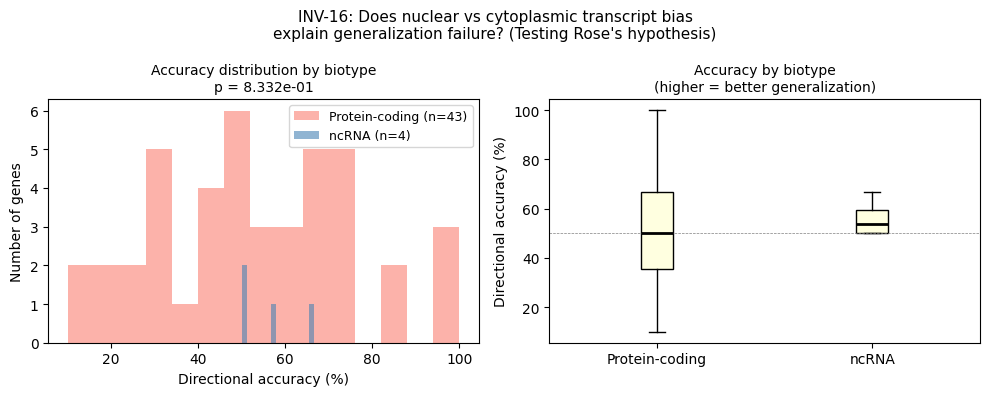


Top 15 genes by accuracy:
    gene  pct_correct        biotype
     Mkx   100.000000 protein-coding
Cntnap5a   100.000000 protein-coding
    Gad2   100.000000 protein-coding
 Cacna1g    85.714286 protein-coding
    Tph2    85.714286 protein-coding
     Npy    75.000000 protein-coding
   Lamp5    75.000000 protein-coding
   Lzts3    71.428571 protein-coding
  Kcnmb2    71.428571 protein-coding
    Maob    71.428571 protein-coding
   Abtb2    66.666667 protein-coding
     Vip    66.666667 protein-coding
 Gm16083    66.666667          ncRNA
   Tafa1    66.666667 protein-coding
   Sntg2    66.666667 protein-coding

Bottom 15 genes by accuracy:
   gene  pct_correct        biotype
   Mobp    10.000000 protein-coding
  Csf1r    11.111111 protein-coding
  Slit2    16.666667 protein-coding
  Plpp4    20.000000 protein-coding
Bhlhe40    25.000000 protein-coding
  Dock2    25.000000 protein-coding
  Stab1    28.571429 protein-coding
  Itga8    28.571429 protein-coding
   Bcan    28.571429 protei

In [23]:
# ── INV-16: Nuclear vs cytoplasmic transcript bias ────────────────────────────
# Rose's hypothesis: snRNA-seq (Liao) vs scRNA-seq (Bagot) methodological gap
# explains part of the generalization failure.
# Test: do nuclear-enriched genes (ncRNA) generalize better than
# cytoplasmic genes (protein-coding)?
# Uses per-gene accuracy from INV-12A and biotype from mygene.

from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# ── Assign biotype to genes in df_12a ────────────────────────────────────────
ncrna_set        = set(ncrna_genes)
protein_cod_set  = set([g for g, t in gene_biotype.items()
                         if t == 'protein-coding'])

df_16 = df_12a.copy()
df_16['biotype'] = df_16['gene'].apply(
    lambda g: 'ncRNA' if g in ncrna_set
              else 'protein-coding' if g in protein_cod_set
              else 'unknown'
)
df_16 = df_16[df_16['biotype'] != 'unknown']

ncrna_acc   = df_16[df_16['biotype'] == 'ncRNA']['pct_correct'].values
prot_acc    = df_16[df_16['biotype'] == 'protein-coding']['pct_correct'].values

print(f"Genes in accuracy analysis: {len(df_16)}")
print(f"  ncRNA:          {len(ncrna_acc)}")
print(f"  protein-coding: {len(prot_acc)}")

if len(ncrna_acc) > 0 and len(prot_acc) > 0:
    stat, p = mannwhitneyu(ncrna_acc, prot_acc, alternative='two-sided')
    print(f"\nncRNA genes:          mean accuracy = {np.mean(ncrna_acc):.1f}%")
    print(f"Protein-coding genes: mean accuracy = {np.mean(prot_acc):.1f}%")
    print(f"Mann-Whitney U: p = {p:.3e}")
    if p < 0.05:
        winner = 'ncRNA' if np.mean(ncrna_acc) > np.mean(prot_acc) else 'protein-coding'
        print(f"\n→ {winner} genes generalize significantly better")
        if winner == 'ncRNA':
            print("→ SUPPORTS Rose's hypothesis: nuclear-enriched transcripts")
            print("  generalize better from snRNA-seq training to scRNA-seq test")
        else:
            print("→ CONTRADICTS Rose's hypothesis")
    else:
        print("\n→ No significant difference — biotype alone does not explain")
        print("  the generalization gap")
else:
    print("Not enough genes in one category to compare")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.hist(prot_acc, bins=15, alpha=0.6, color='salmon',
        label=f'Protein-coding (n={len(prot_acc)})')
ax.hist(ncrna_acc, bins=15, alpha=0.6, color='steelblue',
        label=f'ncRNA (n={len(ncrna_acc)})')
ax.set_xlabel('Directional accuracy (%)', fontsize=10)
ax.set_ylabel('Number of genes', fontsize=10)
ax.set_title(f'Accuracy distribution by biotype\np = {p:.3e}'
             if len(ncrna_acc) > 0 and len(prot_acc) > 0
             else 'Accuracy distribution by biotype', fontsize=10)
ax.legend(fontsize=9)

ax = axes[1]
data_to_plot = [prot_acc, ncrna_acc]
ax.boxplot(data_to_plot,
           tick_labels=['Protein-coding', 'ncRNA'],
           patch_artist=True,
           boxprops=dict(facecolor='lightyellow'),
           medianprops=dict(color='black', linewidth=2))
ax.set_ylabel('Directional accuracy (%)', fontsize=10)
ax.set_title('Accuracy by biotype\n(higher = better generalization)', fontsize=10)
ax.axhline(50, color='gray', linewidth=0.5, linestyle='--', label='chance')

fig.suptitle('INV-16: Does nuclear vs cytoplasmic transcript bias\n'
             'explain generalization failure? (Testing Rose\'s hypothesis)',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/INV16_nuclear_cytoplasmic_bias.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Additional check: are the worst-performing genes enriched for protein-coding?
bottom_genes_bio = df_16.nsmallest(15, 'pct_correct')[['gene','pct_correct','biotype']]
top_genes_bio    = df_16.nlargest(15,  'pct_correct')[['gene','pct_correct','biotype']]
print(f"\nTop 15 genes by accuracy:")
print(top_genes_bio.to_string(index=False))
print(f"\nBottom 15 genes by accuracy:")
print(bottom_genes_bio.to_string(index=False))

Subtype        ρ_magnitude        p_mag   ρ_direction        p_dir
-----------------------------------------------------------------
Astro              -0.181*    4.025e-05       -0.106*    1.615e-02
Endo                0.239*    4.763e-08        0.093*    3.558e-02
GABA               -0.050     2.586e-01        0.084     5.762e-02
L2-5_IT             0.377*    1.106e-18        0.031     4.849e-01
L5-6_NP            -0.320*    1.294e-13       -0.237*    6.143e-08
L5_PT               0.348*    5.366e-16       -0.019     6.690e-01
L6_CT               0.396*    1.490e-20       -0.201*    4.584e-06
Micro               0.005     9.020e-01        0.024     5.941e-01
NFO                -0.146*    9.523e-04       -0.015     7.431e-01
OPC                 0.087     5.054e-02        0.115*    9.355e-03
Oligo               0.011     8.041e-01       -0.150*    6.526e-04

Overall pooled magnitude ρ = -0.033, p = 1.49e-02
Overall pooled direction ρ = 0.108 (from INV-11)


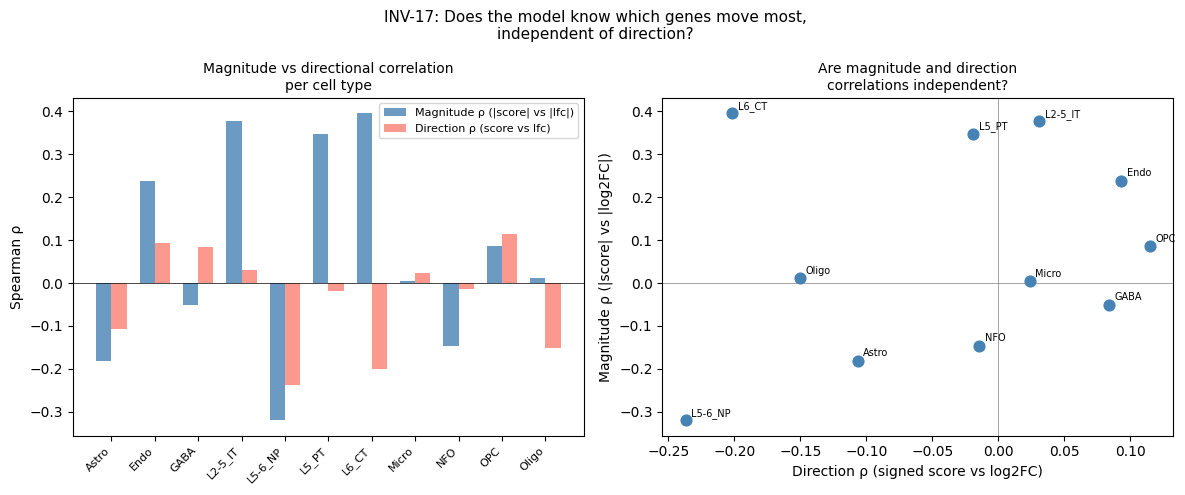

In [25]:
# ── INV-17: Magnitude correlation — does the model know which genes move most? ─
# Directional accuracy (signed score vs log2FC) is one test.
# This tests something different: does the model agree on WHICH genes are
# most dynamically regulated, independent of direction?
# Test: |model score| vs |Bagot log2FC| per cell type (Spearman)
# If positive: model learned regulation-relevance even where direction fails.

from scipy.stats import spearmanr
import matplotlib.pyplot as plt

magnitude_results = {}

for subtype in bagot_signed_scores:
    if subtype not in bagot_lfc:
        continue

    signed = bagot_signed_scores[subtype]           # model signed scores
    lfc_aligned = np.array([
        bagot_lfc[subtype][genes_in_bagot.index(g)]
        if g in genes_in_bagot else np.nan
        for g in final_genes_500
    ])
    valid = ~np.isnan(lfc_aligned)

    abs_score = np.abs(signed[valid])
    abs_lfc   = np.abs(lfc_aligned[valid])

    rho_mag, p_mag = spearmanr(abs_score, abs_lfc)
    rho_dir, p_dir = spearmanr(signed[valid], lfc_aligned[valid])

    magnitude_results[subtype] = {
        'rho_magnitude': rho_mag,
        'p_magnitude':   p_mag,
        'rho_direction': rho_dir,
        'p_direction':   p_dir,
        'n':             valid.sum()
    }

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Subtype':<12} {'ρ_magnitude':>13} {'p_mag':>12} {'ρ_direction':>13} {'p_dir':>12}")
print("-" * 65)
for subtype, d in magnitude_results.items():
    sig_mag = '*' if d['p_magnitude'] < 0.05 else ''
    sig_dir = '*' if d['p_direction'] < 0.05 else ''
    print(f"{subtype:<12} {d['rho_magnitude']:>12.3f}{sig_mag:<1} "
          f"{d['p_magnitude']:>12.3e} "
          f"{d['rho_direction']:>12.3f}{sig_dir:<1} "
          f"{d['p_direction']:>12.3e}")

# Overall pooled magnitude correlation
all_abs_scores, all_abs_lfc = [], []
for subtype, d in magnitude_results.items():
    signed = bagot_signed_scores[subtype]
    lfc_aligned = np.array([
        bagot_lfc[subtype][genes_in_bagot.index(g)]
        if g in genes_in_bagot else np.nan
        for g in final_genes_500
    ])
    valid = ~np.isnan(lfc_aligned)
    all_abs_scores.extend(np.abs(signed[valid]))
    all_abs_lfc.extend(np.abs(lfc_aligned[valid]))

rho_overall_mag, p_overall_mag = spearmanr(all_abs_scores, all_abs_lfc)
print(f"\nOverall pooled magnitude ρ = {rho_overall_mag:.3f}, "
      f"p = {p_overall_mag:.2e}")
print(f"Overall pooled direction ρ = 0.108 (from INV-11)")

# ── Plot: magnitude vs direction rho per cell type ────────────────────────────
subtypes_plot = list(magnitude_results.keys())
rho_mags = [magnitude_results[s]['rho_magnitude'] for s in subtypes_plot]
rho_dirs = [magnitude_results[s]['rho_direction'] for s in subtypes_plot]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: side by side bar chart
x = np.arange(len(subtypes_plot))
w = 0.35
ax = axes[0]
bars1 = ax.bar(x - w/2, rho_mags, w, label='Magnitude ρ (|score| vs |lfc|)',
               color='steelblue', alpha=0.8)
bars2 = ax.bar(x + w/2, rho_dirs, w, label='Direction ρ (score vs lfc)',
               color='salmon', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(subtypes_plot, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Spearman ρ', fontsize=10)
ax.set_title('Magnitude vs directional correlation\nper cell type', fontsize=10)
ax.legend(fontsize=8)

# Right: scatter magnitude vs direction rho
ax = axes[1]
ax.scatter(rho_dirs, rho_mags, s=60, color='steelblue', zorder=3)
for i, s in enumerate(subtypes_plot):
    ax.annotate(s, (rho_dirs[i], rho_mags[i]),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Direction ρ (signed score vs log2FC)', fontsize=10)
ax.set_ylabel('Magnitude ρ (|score| vs |log2FC|)', fontsize=10)
ax.set_title('Are magnitude and direction\ncorrelations independent?', fontsize=10)

fig.suptitle('INV-17: Does the model know which genes move most,\n'
             'independent of direction?', fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/INV17_magnitude_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

DEG count vs directional ρ: ρ = -0.273, p = 4.171e-01
DEG count vs magnitude ρ:   ρ = -0.491, p = 1.252e-01


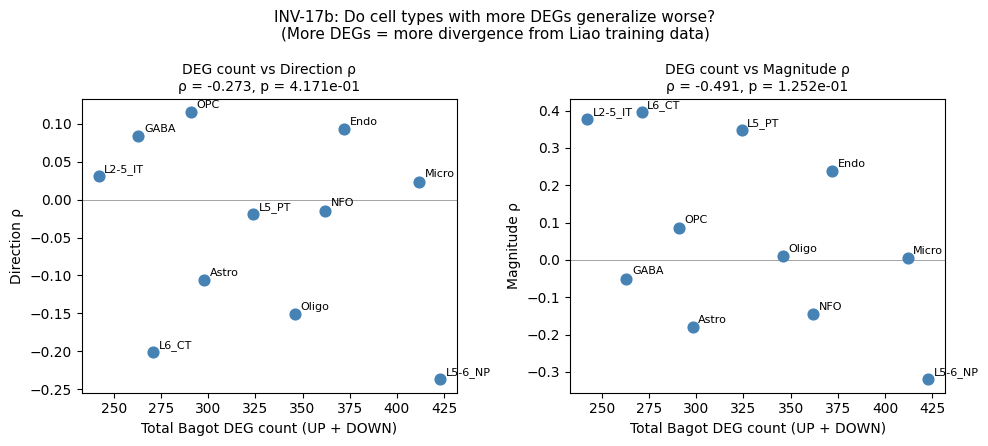

In [27]:
# ── INV-17 supplement: DEG count as predictor of per-cell-type generalization ─
# Question: do cell types with more Bagot DEGs have lower model accuracy?
# If yes: the model fails where the biology diverges most from Liao.
# Data: DEG counts from INV-11E, directional rho from INV-11G,
#       magnitude rho from INV-17.

from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# DEG counts from INV-11E output
bagot_deg_counts = {
    'Astro':   180 + 118,   # UP + DOWN
    'Endo':    276 + 96,
    'GABA':    101 + 162,
    'L2-5_IT':  64 + 178,
    'L5-6_NP':  57 + 366,
    'L5_PT':   117 + 207,
    'L6_CT':    99 + 172,
    'Micro':   164 + 248,
    'NFO':     202 + 160,
    'OPC':      97 + 194,
    'Oligo':   228 + 118,
}

common = [s for s in bagot_deg_counts if s in magnitude_results]

deg_counts = np.array([bagot_deg_counts[s] for s in common])
rho_dirs   = np.array([magnitude_results[s]['rho_direction']  for s in common])
rho_mags   = np.array([magnitude_results[s]['rho_magnitude']  for s in common])

rho_deg_dir, p_deg_dir = spearmanr(deg_counts, rho_dirs)
rho_deg_mag, p_deg_mag = spearmanr(deg_counts, rho_mags)

print(f"DEG count vs directional ρ: ρ = {rho_deg_dir:.3f}, p = {p_deg_dir:.3e}")
print(f"DEG count vs magnitude ρ:   ρ = {rho_deg_mag:.3f}, p = {p_deg_mag:.3e}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, rhos, label, rho_val, p_val in [
    (axes[0], rho_dirs, 'Direction ρ', rho_deg_dir, p_deg_dir),
    (axes[1], rho_mags, 'Magnitude ρ', rho_deg_mag, p_deg_mag),
]:
    ax.scatter(deg_counts, rhos, s=60, color='steelblue', zorder=3)
    for i, s in enumerate(common):
        ax.annotate(s, (deg_counts[i], rhos[i]),
                    fontsize=8, xytext=(4, 3), textcoords='offset points')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Total Bagot DEG count (UP + DOWN)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'DEG count vs {label}\nρ = {rho_val:.3f}, p = {p_val:.3e}',
                 fontsize=10)

fig.suptitle('INV-17b: Do cell types with more DEGs generalize worse?\n'
             '(More DEGs = more divergence from Liao training data)',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/INV17b_deg_count_predictor.png',
            dpi=150, bbox_inches='tight')
plt.show()